In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target  # Actual labels for comparison only

# Dataset exploration
print(X.head())
print(X.info())
print(X.describe())

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

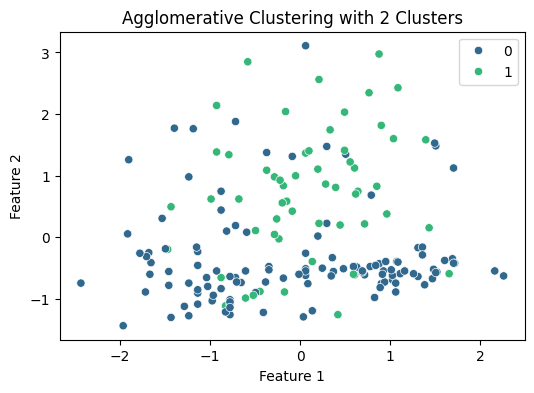

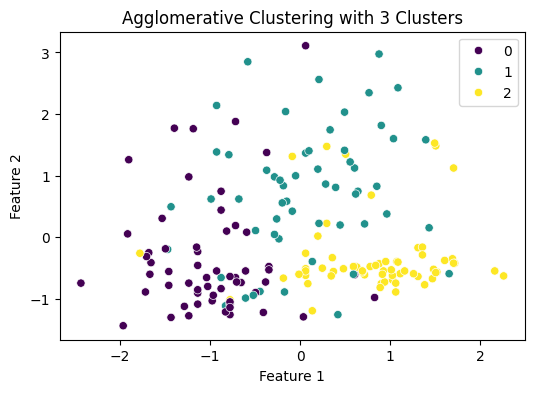

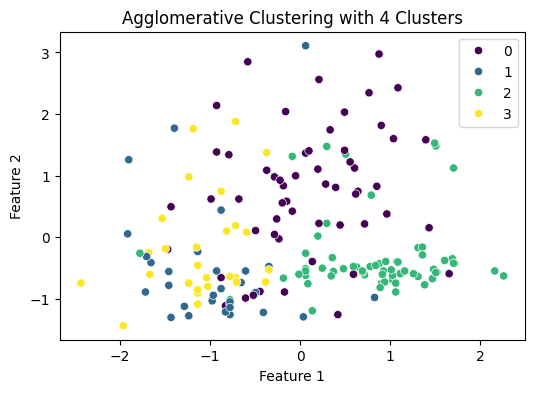

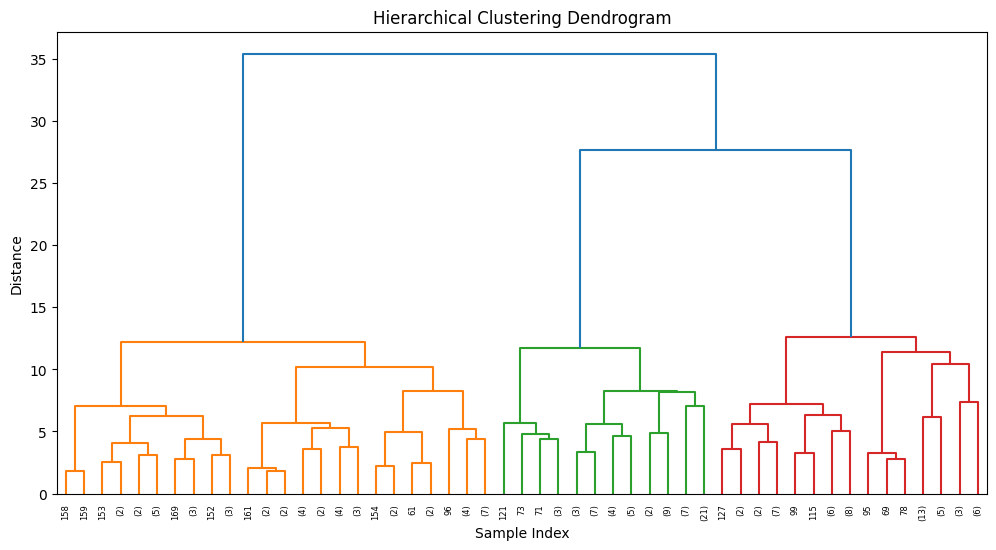

In [2]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Try multiple cluster sizes
for n_clusters in [2, 3, 4]:
    hc = AgglomerativeClustering(n_clusters=n_clusters)
    labels = hc.fit_predict(X_scaled)

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette='viridis')
    plt.title(f'Agglomerative Clustering with {n_clusters} Clusters')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Generate Dendrogram
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

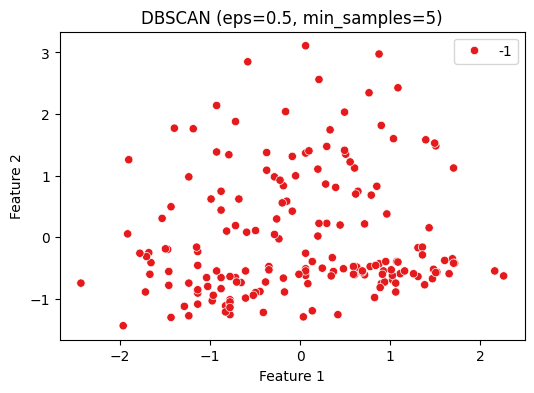

DBSCAN with eps=0.5, min_samples=5
Silhouette Score: -1.000
Homogeneity Score: 0.000
Completeness Score: 1.000
--------------------------------------------------


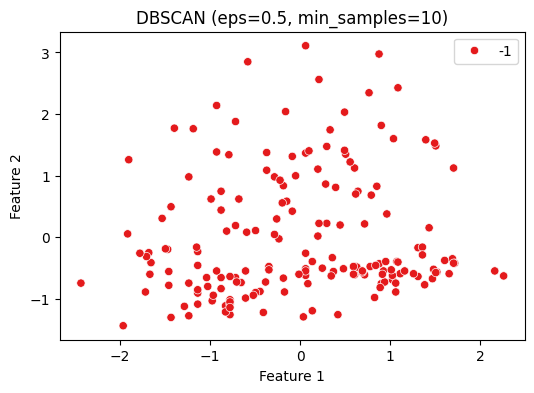

DBSCAN with eps=0.5, min_samples=10
Silhouette Score: -1.000
Homogeneity Score: 0.000
Completeness Score: 1.000
--------------------------------------------------


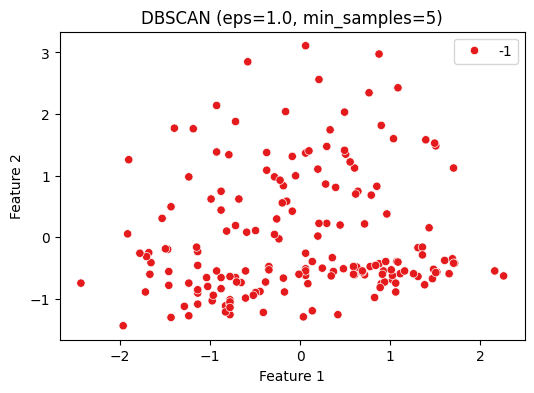

DBSCAN with eps=1.0, min_samples=5
Silhouette Score: -1.000
Homogeneity Score: 0.000
Completeness Score: 1.000
--------------------------------------------------


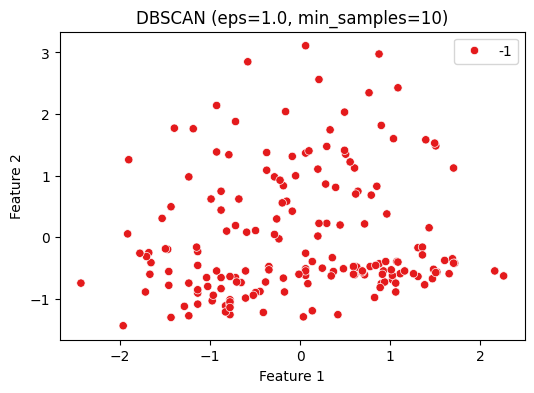

DBSCAN with eps=1.0, min_samples=10
Silhouette Score: -1.000
Homogeneity Score: 0.000
Completeness Score: 1.000
--------------------------------------------------


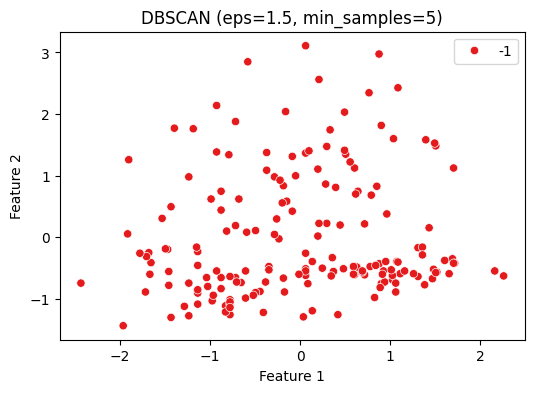

DBSCAN with eps=1.5, min_samples=5
Silhouette Score: -1.000
Homogeneity Score: 0.000
Completeness Score: 1.000
--------------------------------------------------


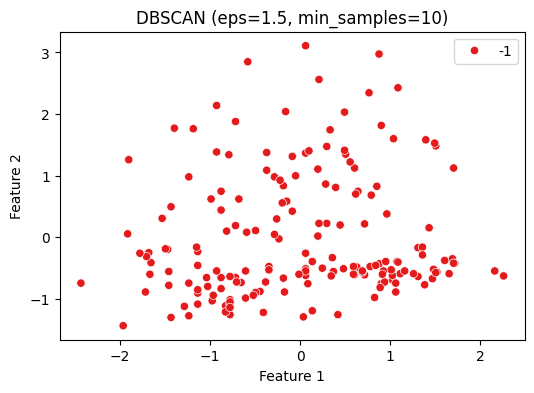

DBSCAN with eps=1.5, min_samples=10
Silhouette Score: -1.000
Homogeneity Score: 0.000
Completeness Score: 1.000
--------------------------------------------------


In [3]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score

# Try different parameters
eps_values = [0.5, 1.0, 1.5]
min_samples_values = [5, 10]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette='Set1', legend='full')
        plt.title(f'DBSCAN (eps={eps}, min_samples={min_samples})')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.show()

        # Exclude noise for silhouette score
        if len(set(labels)) > 1 and -1 in labels:
            mask = labels != -1
            sil_score = silhouette_score(X_scaled[mask], labels[mask])
        elif len(set(labels)) > 1:
            sil_score = silhouette_score(X_scaled, labels)
        else:
            sil_score = -1

        print(f'DBSCAN with eps={eps}, min_samples={min_samples}')
        print(f'Silhouette Score: {sil_score:.3f}')
        print(f'Homogeneity Score: {homogeneity_score(y, labels):.3f}')
        print(f'Completeness Score: {completeness_score(y, labels):.3f}')
        print('-' * 50)